# 09 — Dédoublonnage Système A ↔ First Copilot

**Objectif** — établir si, et dans quelle mesure, First Copilot (notebook 08)
duplique des tickets déjà présents dans le Système A (Intercom, notebooks
01-07), et produire un périmètre consolidé qui ne compte aucun ticket deux
fois.

| | |
|---|---|
| **Entrée** | Système A (`chargement`), First Copilot (notebook 08) |
| **Sorties** | `resultats/tables/09_*.csv` (table de correspondance, bruit de fond par canal, périmètre consolidé) |
| **Suite** | notebook 10 — analyse de First Copilot ; notebook 12 — synthèse consolidée |

**Pourquoi ce notebook existe.** Les deux systèmes tournent en parallèle sur
toute la période opérationnelle (nov. 2025 → juil. 2026). Un cumul brut
(18 094 + 8 005) suppose qu'ils décrivent des populations indépendantes — une
hypothèse qui n'a jamais été vérifiée avant ce notebook, et qui s'avère
fausse pour au moins une partie de First Copilot.

**Méthode retenue — appariement fin par paires**, pas une exclusion en bloc
d'un canal entier : deux clés indépendantes (téléphone + montant + date
proche ; référence de transaction commune), chacune validée contre un bruit
de fond mesuré par permutation (`consolidation.bruit_de_fond`) avant d'être
prise au sérieux — même exigence que le V de Cramér pour la représentativité
(notebook 03).

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, consolidation, systeme_b, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

# Système A -- periemetre operationnel complet (pas seulement le perimetre causal
# du notebook 03) : la question du recouvrement avec B se pose sur tout A.
df_a = chargement.typer(chargement.charger_brut())
tickets_a = chargement.perimetre_operationnel(df_a)

# First Copilot -- notebook 08
tickets_b = systeme_b.charger_tickets()
champs, valeurs = systeme_b.charger_champs_personnalises()

print(f"Système A (période opérationnelle) : {len(tickets_a):,} tickets")
print(f"First Copilot (tous canaux)            : {len(tickets_b):,} tickets")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Système A (période opérationnelle) : 18,049 tickets
First Copilot (tous canaux)            : 8,005 tickets


## 1. Les clés d'appariement

Deux systèmes différents, aucun identifiant commun. Trois champs jouent le
rôle de clé : téléphone client, montant, référence de transaction — chacun
saisi indépendamment des deux côtés, donc chacun une preuve indépendante en
cas d'accord.

Le téléphone côté A combine l'attribut de formulaire et `contacts_contacts`
(`consolidation.telephone_client_a`) ; un piège a été corrigé en le
construisant : `external_id` du JSON contient parfois un email ou un
identifiant hexadécimal plutôt qu'un téléphone, et ces valeurs contiennent
souvent, une fois les caractères non numériques retirés, plus de 8 chiffres
par pur hasard (un UUID est ~37 % de caractères `0-9`). `consolidation.
normaliser_telephone` filtre maintenant sur la forme brute avant d'extraire
les chiffres.

In [2]:
cles_a = consolidation.cles_a(tickets_a)
cles_b = consolidation.cles_b(tickets_b, champs, valeurs)

couverture = pd.DataFrame(
    {
        "Système A": [cles_a["telephone"].notna().mean(), cles_a["montant"].notna().mean(), cles_a["reference"].notna().mean()],
        "First Copilot": [cles_b["telephone"].notna().mean(), cles_b["montant"].notna().mean(), cles_b["reference"].notna().mean()],
    },
    index=["téléphone", "montant", "référence"],
) * 100
chargement.sauver_table(couverture.round(1), "09_couverture_cles")
couverture.round(1)

  -> resultats/tables/09_couverture_cles.csv


,Système A,First Copilot
téléphone,85.5,90.9
montant,40.0,92.7
référence,21.5,45.2


## 2. Appariement

`consolidation.apparier` combine les deux clés : (téléphone, montant, date à
± `config.FENETRE_APPARIEMENT_JOURS` jours) et (référence de transaction
commune). Une paire trouvée par les deux méthodes à la fois porte la
confiance la plus haute disponible dans ce projet.

In [3]:
paires = consolidation.apparier(cles_a, cles_b)
print(f"Paires trouvées : {len(paires):,}")
print(f"Tickets A distincts impliqués : {paires['ticket_id_a'].nunique():,}")
print(f"Tickets B distincts impliqués : {paires['ticket_id_b'].nunique():,}")
print()
print(paires["methode"].value_counts())

Paires trouvées : 2,904
Tickets A distincts impliqués : 1,420
Tickets B distincts impliqués : 1,177

methode
reference                           1926
telephone_montant_date               663
telephone_montant_date+reference     315
Name: count, dtype: int64


## 3. Validation — un taux d'appariement ne veut rien dire sans son bruit de fond

Pour chaque canal de First Copilot, `consolidation.bruit_de_fond` mélange le
téléphone des tickets de ce canal (montant et date restent attachés tels
qu'observés — mélanger les trois conjointement serait un test inerte, voir
la docstring de la fonction) et réapplique l'appariement. Répété 100 fois par
canal.

In [4]:
lignes = []
for canal_nom, ids_canal in tickets_b.groupby("canal")["id"]:
    cb_canal = cles_b.loc[cles_b.index.isin(ids_canal)]
    obs = consolidation.apparier_telephone_montant_date(cles_a, cb_canal)
    n_obs = obs["ticket_id_b"].nunique()
    bruit = consolidation.bruit_de_fond(cles_a, cb_canal, methode="telephone_montant_date", n_permutations=100, graine=1)
    lignes.append(
        {
            "canal": canal_nom,
            "n_tickets": len(cb_canal),
            "apparies_observes": n_obs,
            "pct_observe": round(n_obs / len(cb_canal) * 100, 1),
            "bruit_moyen": round(bruit["moyenne"], 2),
            "ratio_signal_bruit": round(n_obs / max(bruit["moyenne"], 0.01), 1),
        }
    )

resultat_bruit = pd.DataFrame(lignes).sort_values("pct_observe", ascending=False)
chargement.sauver_table(resultat_bruit, "09_bruit_de_fond_par_canal", index=False)
resultat_bruit

  -> resultats/tables/09_bruit_de_fond_par_canal.csv


,canal,n_tickets,apparies_observes,pct_observe,bruit_moyen,ratio_signal_bruit
5,INTERCOM,3180,687,21.6,3.11,220.9
0,APPEL,498,18,3.6,0.11,163.6
4,EN_AGENCE,2082,66,3.2,0.16,412.5
7,WHATSAPP,258,6,2.3,0.07,85.7
3,COURRIER,1031,18,1.7,0.07,257.1
2,COLLEGUE,345,6,1.7,0.06,100.0
1,AUTRE,301,5,1.7,0.06,83.3
6,MAIL,305,4,1.3,0.00,400.0


**Tous les canaux dépassent leur bruit de fond** — y compris `EN_AGENCE` et
`COURRIER`, contrairement à l'attente initiale d'une exploration préalable
plus grossière. Mais l'écart de **magnitude** reste massif et c'est lui qui
compte pour la décision : `INTERCOM` a un taux d'appariement brut de 21,6 %,
les sept autres canaux entre 1,3 % et 3,6 %. Le bruit de fond lui-même est
minuscule sur tous les canaux (< 3,2 attendu par hasard, souvent < 0,2) —
cohérent avec des clés précises (téléphone exact + montant exact + fenêtre de
3 jours), pas avec un test qui laisserait passer n'importe quoi.

**Lecture retenue** : `INTERCOM` est bien le canal où la duplication est
massive et attendue (ressaisie manuelle d'un ticket Intercom déjà ouvert,
notebook 08). Les quelques dizaines de correspondances sur les autres canaux
sont réelles mais rares — un client qui a par ailleurs utilisé Intercom pour
la même affaire, ou une coïncidence sur un montant rond et une date proche.
C'est précisément pour ce genre de cas que l'appariement fin par paires (et
non une exclusion de canal en bloc) a été retenu : ces quelques dizaines de
tickets sont retirés individuellement, sans supposer que tout le canal l'est.

## 4. Sens du flux

Sur les paires trouvées par la clé (téléphone, montant, date), l'écart en
jours (`date_b - date_a`) dit qui a été créé en premier.

A précède B : 90.8 % des paires (n=978)
Écart médian : 0.06 jours


  -> resultats/figures/09_sens_du_flux.png


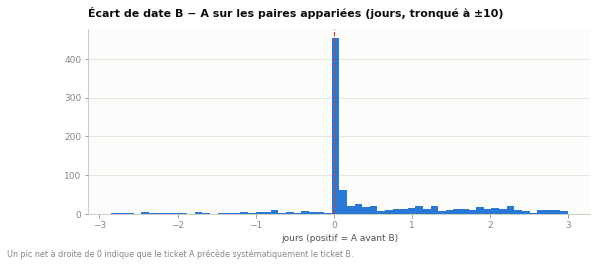

In [5]:
paires_tmd = paires[paires["methode"].str.contains("telephone_montant_date")]
a_precede_b = (paires_tmd["ecart_jours"] > 0).mean()
print(f"A précède B : {a_precede_b * 100:.1f} % des paires (n={len(paires_tmd):,})")
print(f"Écart médian : {paires_tmd['ecart_jours'].median():.2f} jours")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(paires_tmd["ecart_jours"].clip(-10, 10), bins=60, color=viz.SERIES[0])
ax.axvline(0, color=viz.STATUT["critique"], linestyle="--", linewidth=1.2)
ax.set_title("Écart de date B − A sur les paires appariées (jours, tronqué à ±10)")
ax.set_xlabel("jours (positif = A avant B)")
ax.grid(axis="x", visible=False)
viz.annoter_source(fig, "Un pic net à droite de 0 indique que le ticket A précède systématiquement le ticket B.")
viz.sauver(fig, "09_sens_du_flux")
plt.show()

## 5. Périmètre consolidé retenu

Règle : le Système A reste intact (aucun de ses tickets n'est retiré — c'est
lui qui précède, jamais l'inverse, § 4). First Copilot perd les tickets
effectivement appariés à un ticket A, quel que soit leur canal — un ticket
`EN_AGENCE` apparié reste un doublon, même si son canal est globalement peu
recoupé (§ 3).

In [6]:
tickets_b_retenus = consolidation.tickets_b_non_apparies(tickets_b, paires)

par_canal = pd.DataFrame(
    {
        "avant_dedoublonnage": tickets_b["canal"].value_counts(),
        "apres_dedoublonnage": tickets_b_retenus["canal"].value_counts(),
    }
).fillna(0).astype(int)
par_canal["doublons_retires"] = par_canal["avant_dedoublonnage"] - par_canal["apres_dedoublonnage"]
chargement.sauver_table(par_canal.sort_values("doublons_retires", ascending=False), "09_perimetre_b_par_canal")

print("PÉRIMÈTRE CONSOLIDÉ")
print(f"  Système A (inchangé)                : {len(tickets_a):,}")
print(f"  First Copilot avant dédoublonnage        : {len(tickets_b):,}")
print(f"  First Copilot après dédoublonnage        : {len(tickets_b_retenus):,}")
print(f"  Doublons retirés                     : {len(tickets_b) - len(tickets_b_retenus):,}")
print(f"  TOTAL CONSOLIDÉ (A + B dédupliqué)   : {len(tickets_a) + len(tickets_b_retenus):,}")
print()
par_canal.sort_values("doublons_retires", ascending=False)

  -> resultats/tables/09_perimetre_b_par_canal.csv
PÉRIMÈTRE CONSOLIDÉ
  Système A (inchangé)                : 18,049
  First Copilot avant dédoublonnage        : 8,005
  First Copilot après dédoublonnage        : 6,828
  Doublons retirés                     : 1,177
  TOTAL CONSOLIDÉ (A + B dédupliqué)   : 24,877



,avant_dedoublonnage,apres_dedoublonnage,doublons_retires
canal,,,
INTERCOM,3180,2293,887
EN_AGENCE,2082,1970,112
AUTRE,301,242,59
COURRIER,1031,996,35
APPEL,498,470,28
COLLEGUE,345,322,23
MAIL,305,287,18
WHATSAPP,258,243,15


In [7]:
# Table de correspondance -- aucune donnee personnelle (identifiants + ecart + methode
# uniquement), verse dans resultats/tables/ sans risque.
chargement.sauver_table(paires.reset_index(drop=True), "09_correspondance_a_b", index=False)

  -> resultats/tables/09_correspondance_a_b.csv


## 6. Limites — ce dédoublonnage sous-estime probablement les vrais doublons

1. **Le taux de faux négatifs n'est pas nul.** Un doublon réel sans téléphone,
   montant ni référence commune renseignés des deux côtés ne peut pas être
   détecté par cette méthode. La couverture des clés (§ 1) borne directement
   ce risque : ce qui n'est jamais renseigné ne peut jamais matcher.
2. **La fenêtre de ± `config.FENETRE_APPARIEMENT_JOURS` jours** est un
   compromis, pas une certitude : un agent qui ressaisit un ticket plusieurs
   jours après peut être manqué. Élargir la fenêtre récupérerait des vrais
   positifs au prix de plus de faux positifs — le bruit de fond (§ 3) est la
   référence pour juger si l'élargir resterait défendable.
3. **Le bruit de fond n'est jamais nul, même sur les canaux physiques** (§ 3)
   — quelques correspondances sur `EN_AGENCE` ou `COURRIER` peuvent être des
   coïncidences (même montant rond, dates proches, deux clients différents)
   plutôt que de vrais doublons. Le taux d'erreur exact de ces quelques
   dizaines de cas n'est pas mesuré individuellement, seulement borné en
   moyenne par le bruit de fond du canal (§ 3).
4. **Ce dédoublonnage ne traite qu'A → B.** Il ne dit rien des doublons
   internes à B lui-même (un client qui relance en `EN_AGENCE` puis en
   `APPEL` pour la même affaire), ni des doublons internes à A déjà traités
   par le notebook 05 (récidive).